In [15]:
import geopandas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
mex = geopandas.read_file('mexican-states.shp')

# También puedes cargar el geojson (mismo resultado):
mex = geopandas.read_file('estados_mx.geojson')

mex[["name", "geometry"]]  # solo columnas de interés

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


,name,geometry
0,Aguascalientes,"POLYGON ((-102.7453 21.72005, -102.74859 21.72..."
1,Colima,"MULTIPOLYGON (((-103.48859 18.96489, -103.4884..."
2,Tlaxcala,"POLYGON ((-98.5415 19.46082, -98.54158 19.4607..."
3,Ciudad de México,"POLYGON ((-99.2787 19.1317, -99.28259 19.13821..."
4,Morelos,"POLYGON ((-98.90339 19.03848, -98.90061 19.038..."
5,México,"POLYGON ((-100.13794 20.04431, -100.13759 20.0..."
6,Hidalgo,"POLYGON ((-99.73527 20.56486, -99.73525 20.564..."
7,Puebla,"POLYGON ((-97.26671 19.38249, -97.26549 19.381..."
8,Nuevo León,"POLYGON ((-99.94766 23.49713, -99.94611 23.490..."
9,Coahuila de Zaragoza,"POLYGON ((-103.50895 25.27801, -103.50984 25.2..."


### Mapa base y contorno

<Axes: >

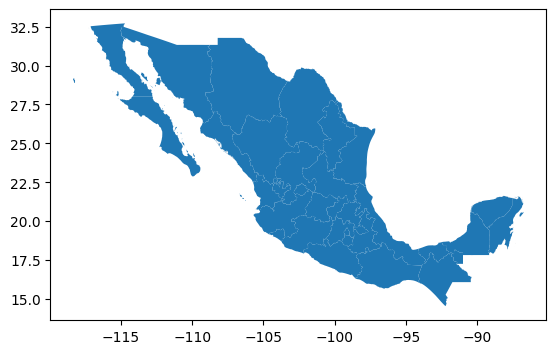

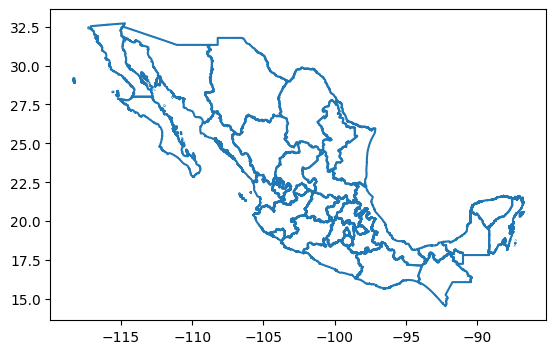

In [18]:
# Mapa relleno (polígonos completos)
mex.plot()

# Solo contornos
mex.boundary.plot()

### Mapa coroplético (población por estado)

<Axes: >

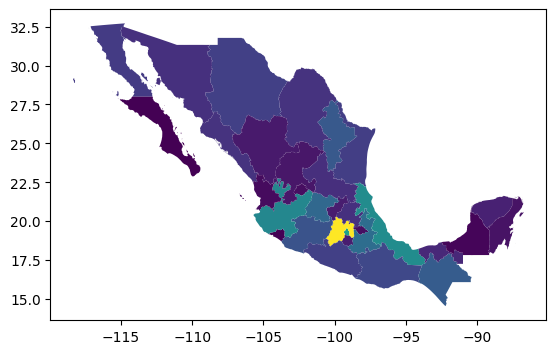

In [ ]:
columnas = ['Entidad', 'Total_2000', 'Hombres_2000', 'Mujeres_2000',
            'Total_2005', 'Hombres_2005', 'Mujeres_2005',
            'Total', 'Hombres', 'Mujeres']

Poblacion = pd.read_csv(
    'Tabulado_INEGI_2010.csv',
    encoding='utf-8-sig',   # quita el BOM invisible al inicio del archivo
    skiprows=3,             # salta las 2 filas de encabezado + "Estados Unidos Mexicanos"
    header=None,
    names=columnas
)

Poblacion[['Entidad', 'Total']]  # solo nos interesa la población total de 2010

# Unimos geometría + población por nombre de estado
mexgdf = mex.merge(Poblacion, left_on='name', right_on='Entidad')
mexgdf[['name', 'Entidad', 'geometry', 'Total']]

# Graficamos coloreando según la columna 'Total'
mexgdf.plot(column='Total')

### Personalizar leyenda

<Axes: >

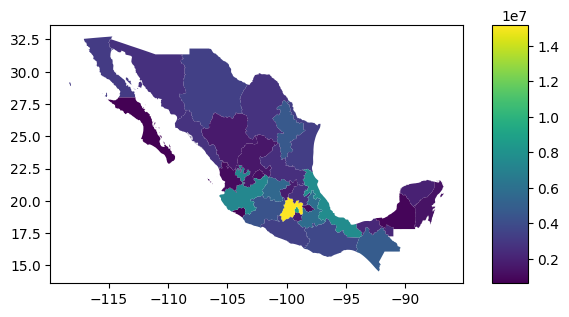

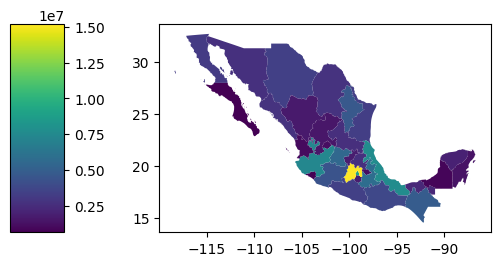

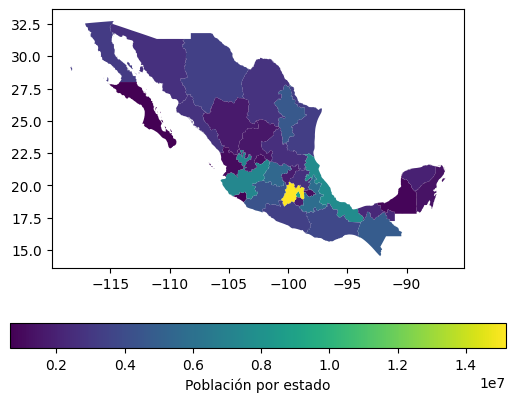

In [30]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Leyenda a la derecha
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="8%", pad=0.1)
mexgdf.plot(column='Total', ax=ax, legend=True, cax=cax)

# Leyenda a la izquierda, más ancha
fig, ax = plt.subplots(1, 1)
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="15%", pad=0.8)
mexgdf.plot(column='Total', ax=ax, legend=True, cax=cax)

# Leyenda horizontal con etiqueta descriptiva
fig, ax = plt.subplots(1, 1)
mexgdf.plot(column='Total', ax=ax, legend=True,
            legend_kwds={'label': "Población por estado",
                         'orientation': "horizontal"})

### Probar distintos colormaps

<Axes: >

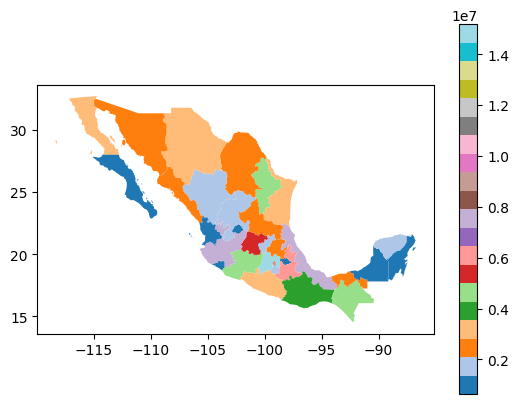

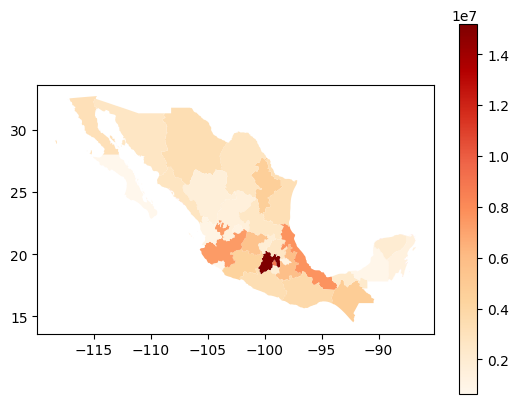

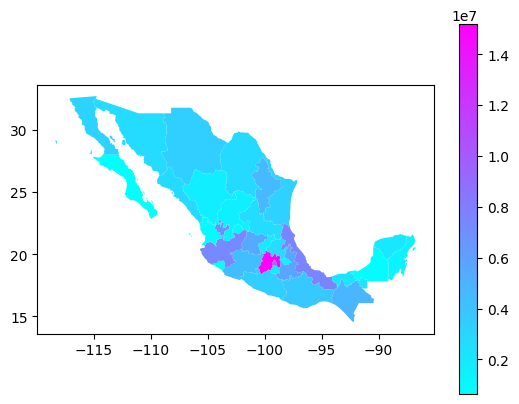

In [31]:
mexgdf.plot(column='Total', cmap='tab20', legend=True)   # categórico
mexgdf.plot(column='Total', cmap='OrRd', legend=True)    # secuencial
mexgdf.plot(column='Total', cmap='cool', legend=True)    # otro esquema

### Cargar capitales y unificar CRS

In [ ]:
df = pd.read_csv('mexican-capitals.csv')

# Convertimos lat/long en geometría tipo Point
capitales = geopandas.GeoDataFrame(
    df, geometry=geopandas.points_from_xy(df.Long, df.Lat)
)
capitales[:5]

# Aseguramos que compartan el mismo CRS que el mapa de estados
capitales = capitales.set_crs(mex.crs)
mexgdf = mexgdf.to_crs(mex.crs)  # si hiciera falta re-alinear
mexgdf.crs  # para verificar

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Graficar capas (estados + capitales) usando ax

<Axes: >

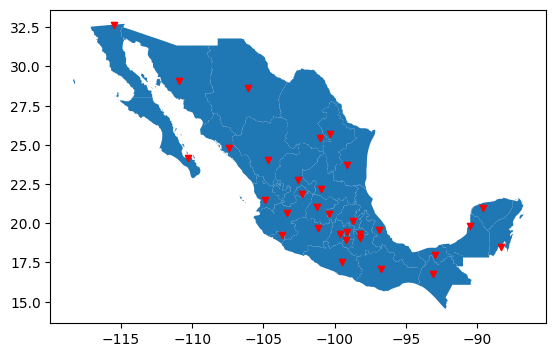

In [38]:
# Mapa base (estados)
mapa = mex.plot()

# Capa de capitales encima
capitales.plot(ax=mapa, marker='v', color='red', markersize=20)

### Graficar capas usando Matplotlib (fig, ax)

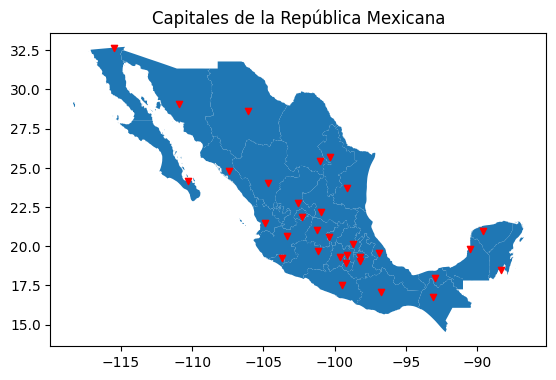

In [39]:
fig, ax = plt.subplots()
ax.set_title('Capitales de la República Mexicana')
ax.set_aspect('equal')  # correspondencia 1:1 en los ejes

mex.plot(ax=ax)                                           # capa base
capitales.plot(ax=ax, marker='v', color='red', markersize=20)  # capa encima

plt.show()

### Controlar el orden con zorder

<Axes: >

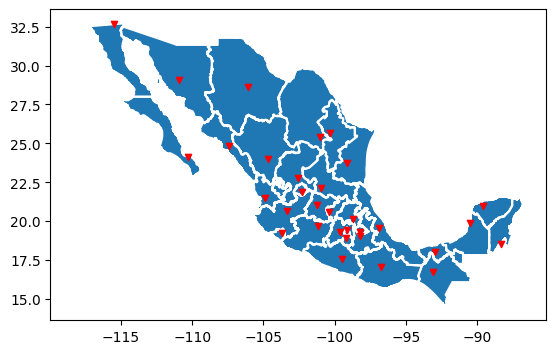

In [40]:
# Estados (fondo) -> zorder 1
# Bordes en blanco (medio) -> zorder 2
# Capitales (arriba) -> zorder 3

mapa = capitales.plot(marker='v', color='red', markersize=20, zorder=3)
mex.plot(ax=mapa, zorder=1)
mex.boundary.plot(ax=mapa, zorder=2, color='white')

# Reto

## Pruébate
Recuerda que todos los ejemplos y ejercicios los puedes realizar utilizando 
Google Colab. Si aún no lo has descargado, accede a la plataforma copian
do y pegando el siguiente enlace: https://colab.research.google.com/
Ahora que ya sabes cómo graficar mapas simples y con capas utilizando 
GeoPandas, te proponemos el siguiente desafío:
### 1
Define los datos a representar.Consigue una serie de datos que contengan información que puedas representar en capas (es decir, varias columnas con geometrías que se puedan visualizar en un mismo mapa).
### 2 
1. Prepara tu entorno de trabajo
2. Crea una libreta en Google Colab para este ejercicio.
3. Monta Google Drive para poder acceder a los archivos que necesitas.
4. Carga los datos desde archivos CSV, XLS o SHP en dos o más GeoDataFrames.
5. Imprime los primeros 5 renglones de cada GeoDataFrame para explorar su contenido.
6. Imprime la geometría de los GeoDataFrames para visualizar qué tipo de datos geográficos se están manejando
### 3
1. Crea el mapa con capas
2. Genera una visualización donde combines las distintas capas de información.
3. Asegúrate de usar un colormap adecuado para representar los datos de manera clara.
4. Añade etiquetas en los polígonos para identificar regiones importantes.
5. Dibuja los límites entre las regiones para hacer más comprensible el mapa.

c:\Users\diego\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: mexican-states.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


<Axes: >

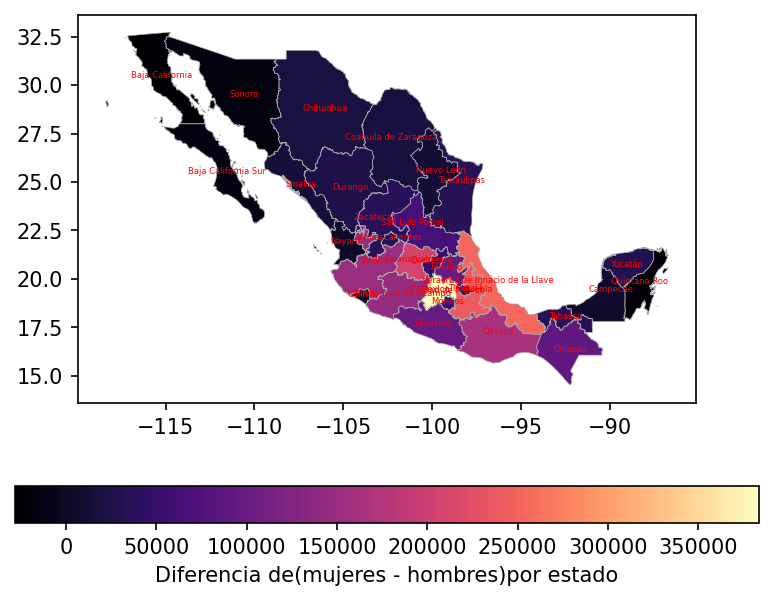

In [44]:
# Lee archivos de estados y de población
mex = geopandas.read_file('mexican-states.shp')

# Realiza el merge para relacionar de acuerdo a la entidad (estado)
mexgdf = mex.merge(Poblacion, left_on=['name'], right_on=['Entidad'])
mexgdf[['name', 'Entidad', 'geometry', 'Total']]

# Calcula la diferencia de mujeres - hombres por estado
mexgdf['dif_HM'] = mexgdf['Mujeres']-mexgdf['Hombres']

# Cambia la resolución de la gráfica para poder apreciarla mejor
fig = plt.figure(dpi=150)

# Grafica la columna de diferencia usando el colormap magma
mapa = mexgdf.plot(column='dif_HM',
                    ax = plt.gca(),
                    legend=True,
                    cmap='magma',
                    legend_kwds={ 'label': 'Diferencia de(mujeres - hombres)por estado','orientation':'horizontal'});

# Encuentra puntos representativos de cada polígono para ponerles una etiqueta
mexgdf['coords'] = mexgdf['geometry'].apply(lambda x:x.representative_point().coords[:])
mexgdf['coords'] = [coords[0] for coords in mexgdf['coords']]

# Pon las etiquetas en color rojo
for idx, row in mexgdf.iterrows():
    plt.annotate(text=row['name'], xy=row['coords'],horizontalalignment='center',fontsize=4,color='red')

# Pon una capa encima de los estados para resaltar los límites entre ellos
# con un color gris claro (#aaa) y reduce el grueso de la línea

mex.boundary.plot(ax=mapa, color='#aaa', linewidth=0.3)